# Upgrading the model
<div dir='rtl'>
    <p>الان بدلاً من ان ندخل للأله سؤال واحد نريد ان ندخل له 3 اسئله لتحسين التوفعات</p>
    <p>مثال على السؤال:</p>
    <p>إذا كانت هناك لعبه مبعاتها فى امريكا الشماليه <code>NA_Sales</code> = ؟ و مبيعاتها فى اوروبا <code>EU_Sales</code> = ؟ ومبيعاتها فى اليابان <code>JP_Sales</code> = ؟، إذاً ما هو توقعك للمبيعات العالميه <code>Global_Sales</code> لهذه اللعبه؟</p>
    <p>إذاً نستنتج ان الـ <code>Futures</code> هما:</p>
    <ol>
        <li>NA_Sales</li>
        <li>EU_Sales</li>
        <li>JP_Sales</li>
    </ol>
    <p>و الـ <code>Target</code> هو: <code>Global_Sales</code></p>
</div>

## Setup the data

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(
    "vgsales.csv",
    dtype={
        "NA_Sales": np.float32,
        "EU_Sales": np.float32,
        "JP_Sales": np.float32,
        "Other_Sales": np.float32,
        "Global_Sales": np.float32,
    }
)
df.drop(columns=["Rank", "Name", "Platform", "Year", "Genre", "Publisher"], inplace=True)
df['Global_Sales'] = df[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum(axis=1).round(2)
df.head(10)

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,41.490002,29.02,3.77,8.46,82.739998
1,29.080000,3.58,6.81,0.77,40.240002
2,15.850000,12.88,3.79,3.31,35.830002
3,15.750000,11.01,3.28,2.96,33.000000
4,11.270000,8.89,10.22,1.00,31.379999
5,23.200001,2.26,4.22,0.58,30.260000
6,11.380000,9.23,6.50,2.90,30.010000
7,14.030000,9.20,2.93,2.85,29.010000
8,14.590000,7.06,4.70,2.26,28.610001
9,26.930000,0.63,0.28,0.47,28.309999


## Defining
Futures = `["NA_Sales", "EU_Sales", "JP_Sales"]`

Target = `"Global_Sales"`

In [31]:
X = df[["NA_Sales", "EU_Sales", "JP_Sales"]]
Y = df['Global_Sales']

x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

## Create the Model and Train it

In [32]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
f"Score: {model.score(x_test, y_test) * 100:.2f}%"

'Score: 99.51%'

## Testing the model

In [82]:
prediction = model.predict(x_test)
dt = pd.DataFrame(
    {
        "NA_Sales": x_test['NA_Sales'].values,
        "EU_Sales": x_test['EU_Sales'].values,
        "JP_Sales": x_test['JP_Sales'].values,
        "Global_Sales": y_test.values,
        "Predection": prediction
    }
)
dt

,NA_Sales,EU_Sales,JP_Sales,Global_Sales,Predection
0,0.01,0.11,0.00,0.15,0.151928
1,0.32,0.04,0.01,0.41,0.399478
2,0.00,0.02,0.00,0.02,0.030756
3,0.01,0.01,0.00,0.02,0.028910
4,0.20,0.11,0.00,0.36,0.350593
...,...,...,...,...,...
3315,0.20,0.24,0.00,0.49,0.510516
3316,0.71,1.02,0.00,2.04,2.003313
3317,0.00,0.00,0.02,0.02,0.025202
3318,0.05,0.04,0.00,0.10,0.107640


## Graph the Data
<div dir='rtl'>
    <p>الان نريد عرض كيف هو مدى ذكاء الأله، للأسف لا يمكننا عرضها بالطريقه السابقه لأننا الان لدينا 3 اسئله</p>
    <ol>
        <li>NA_Sales</li>
        <li>EU_Sales</li>
        <li>JP_Sales</li>
    </ol>
    <p>لدالك بدلاً من عرض الأسئله، سوف نعرض النتيجه ومقارنتها بالواقع</p>
</div>

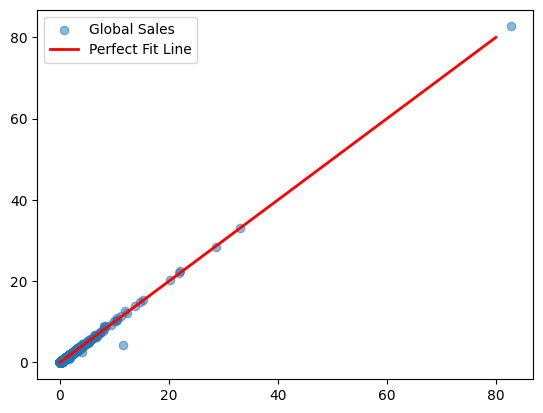

In [95]:
x_axis = np.array([0,80], dtype=np.int8)
y_axis = np.array([0,80], dtype=np.int8)

plt.scatter(y_test, prediction, alpha=0.5, label="Global Sales")
plt.plot(x_axis, y_axis, color='red', label="Perfect Fit Line", lw=2)
plt.legend()
plt.show()